In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("kasatria_dataset.csv")

df.head()

,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter
0,Ali,22,M,15000,Highschool,Samsung Galaxy S3,x,x,x,x,NaN,NaN,NaN
1,Mutu,25,M,30000,Diploma,HTC One Note,x,x,x,NaN,NaN,NaN,NaN
2,Lim,33,M,36000,Diploma,iPhone 5,x,x,x,NaN,x,NaN,NaN
3,Angie,47,F,45000,Diploma,iPhone 6s,x,NaN,NaN,x,x,x,x
4,Jack,26,M,25000,Degree,Xiaomi MI3,x,x,x,NaN,NaN,NaN,NaN


In [2]:
# Check dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20
Columns: 13


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           20 non-null     object
 1   Age            20 non-null     int64 
 2   Gender         20 non-null     object
 3   Annual Income  20 non-null     int64 
 4   Education      20 non-null     object
 5   Phone Owned    20 non-null     object
 6   Email          19 non-null     object
 7   Web            13 non-null     object
 8   Mobile         14 non-null     object
 9   Walk-in        5 non-null      object
 10  Video Call     8 non-null      object
 11  Phone Call     5 non-null      object
 12  Letter         3 non-null      object
dtypes: int64(2), object(11)
memory usage: 2.2+ KB


In [4]:
# Check for missing values
print(df.isnull().sum())

Name              0
Age               0
Gender            0
Annual Income     0
Education         0
Phone Owned       0
Email             1
Web               7
Mobile            6
Walk-in          15
Video Call       12
Phone Call       15
Letter           17
dtype: int64


### Data Quality Note

The contact-method columns use `x` to indicate that a contact method was used, while blank cells indicate that the method was not selected. Therefore, blank values in these columns are treated as "not used" rather than missing observations.



In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df.describe()

,Age,Annual Income
count,20.000000,20.000000
mean,31.550000,38710.000000
std,10.644865,32212.745108
min,19.000000,12000.000000
25%,22.750000,16750.000000
50%,27.500000,27500.000000
75%,36.000000,42750.000000
max,54.000000,120000.000000


In [7]:
df[df["Age"].isnull() | df["Annual Income"].isnull()]

,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter


In [8]:
print("Gender:")
print(df["Gender"].value_counts(dropna=False))

print("\nEducation:")
print(df["Education"].value_counts(dropna=False))

Gender:
Gender
M    11
F     9
Name: count, dtype: int64

Education:
Education
Diploma       6
Primary       6
Degree        4
Highschool    2
Masters       2
Name: count, dtype: int64


In [9]:
contact_cols = [
    "Email",
    "Web",
    "Mobile",
    "Walk-in",
    "Video Call",
    "Phone Call",
    "Letter"
]

for col in contact_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Email:
Email
x      19
NaN     1
Name: count, dtype: int64

Web:
Web
x      13
NaN     7
Name: count, dtype: int64

Mobile:
Mobile
x      14
NaN     6
Name: count, dtype: int64

Walk-in:
Walk-in
NaN    15
x       5
Name: count, dtype: int64

Video Call:
Video Call
NaN    12
x       8
Name: count, dtype: int64

Phone Call:
Phone Call
NaN    15
x       5
Name: count, dtype: int64

Letter:
Letter
NaN    17
x       3
Name: count, dtype: int64


In [13]:
print("Rows with missing values:")
display(df[df.isnull().any(axis=1)])

Rows with missing values:


,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter
0,Ali,22,M,15000,Highschool,Samsung Galaxy S3,x,x,x,x,NaN,NaN,NaN
1,Mutu,25,M,30000,Diploma,HTC One Note,x,x,x,NaN,NaN,NaN,NaN
2,Lim,33,M,36000,Diploma,iPhone 5,x,x,x,NaN,x,NaN,NaN
3,Angie,47,F,45000,Diploma,iPhone 6s,x,NaN,NaN,x,x,x,x
4,Jack,26,M,25000,Degree,Xiaomi MI3,x,x,x,NaN,NaN,NaN,NaN
5,Mambutu,35,M,18000,Primary,Hua Wei Honour 6,x,x,x,x,x,x,NaN
6,Pierre,54,M,120000,Degree,Nokia E63,x,NaN,NaN,NaN,NaN,x,x
7,Valerie,32,F,80000,Masters,iPhone 3Gs,x,x,x,NaN,x,NaN,NaN
8,Farah,19,F,12000,Primary,HTC Mozart 7,NaN,NaN,x,x,NaN,x,NaN
9,Muhammad,22,M,16000,Primary,HTC One E8,x,x,x,NaN,NaN,NaN,NaN


In [11]:
print("Gender values:")
print(df["Gender"].unique())

print("\nEducation values:")
print(df["Education"].unique())

Gender values:
['M' 'F']

Education values:
['Highschool' 'Diploma' 'Degree' 'Primary' 'Masters']


In [12]:
print("\nDataset shape:")
print(df.shape)


Dataset shape:
(20, 13)


In [14]:
contact_cols = [
    "Email",
    "Web",
    "Mobile",
    "Walk-in",
    "Video Call",
    "Phone Call",
    "Letter"
]

df[contact_cols] = df[contact_cols].fillna("").apply(
    lambda col: col.map(lambda x: 1 if x == "x" else 0)
)

df.head()

,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter
0,Ali,22,M,15000,Highschool,Samsung Galaxy S3,1,1,1,1,0,0,0
1,Mutu,25,M,30000,Diploma,HTC One Note,1,1,1,0,0,0,0
2,Lim,33,M,36000,Diploma,iPhone 5,1,1,1,0,1,0,0
3,Angie,47,F,45000,Diploma,iPhone 6s,1,0,0,1,1,1,1
4,Jack,26,M,25000,Degree,Xiaomi MI3,1,1,1,0,0,0,0


In [15]:
for col in contact_cols:
    print(f"{col}: {df[col].sum()} customers")

Email: 19 customers
Web: 13 customers
Mobile: 14 customers
Walk-in: 5 customers
Video Call: 8 customers
Phone Call: 5 customers
Letter: 3 customers


In [16]:
df.to_csv("kasatria_dataset_analysis_ready.csv", index=False)


print("Analysis-ready dataset saved.")

In [19]:
# Question 1: Median age

median_age = df["Age"].median()

print(
    f"The median age of the subjects is {median_age} years."
)

The median age of the subjects is 27.5 years.


In [21]:
# Question 2: Average salary difference between Diploma and Master's holders

diploma_avg = df.loc[df["Education"] == "Diploma", "Annual Income"].mean()
masters_avg = df.loc[df["Education"] == "Masters", "Annual Income"].mean()

salary_difference = masters_avg - diploma_avg

# Convert annual income difference to monthly
monthly_difference = salary_difference / 12

print(f"Average annual income - Diploma: RM{diploma_avg:,.2f}")
print(f"Average annual income - Masters: RM{masters_avg:,.2f}")
print(f"Average annual difference: RM{salary_difference:,.2f}")
print(f"Average monthly difference: approximately RM{monthly_difference:,.2f}")

Average annual income - Diploma: RM36,000.00
Average annual income - Masters: RM77,500.00
Average annual difference: RM41,500.00
Average monthly difference: approximately RM3,458.33


In [22]:
# Question 3: Does age affect salary for Diploma holders?

diploma_df = df[df["Education"] == "Diploma"].copy()

print(diploma_df[["Name", "Age", "Annual Income"]])

       Name  Age  Annual Income
1      Mutu   25          30000
2       Lim   33          36000
3     Angie   47          45000
11   Trevor   25          30000
12  Melinda   39          33000
13   Aishah   45          42000


In [23]:
correlation = diploma_df["Age"].corr(diploma_df["Annual Income"])

print(f"Correlation between age and annual income: {correlation:.3f}")

Correlation between age and annual income: 0.913


In [24]:
from scipy.stats import linregress

x = diploma_df["Age"]
y = diploma_df["Annual Income"]

regression = linregress(x, y)

print(f"Slope: RM{regression.slope:,.2f} per year of age")
print(f"Intercept: RM{regression.intercept:,.2f}")
print(f"R-squared: {regression.rvalue ** 2:.3f}")
print(f"P-value: {regression.pvalue:.4f}")

Slope: RM598.27 per year of age
Intercept: RM14,661.85
R-squared: 0.834
P-value: 0.0110


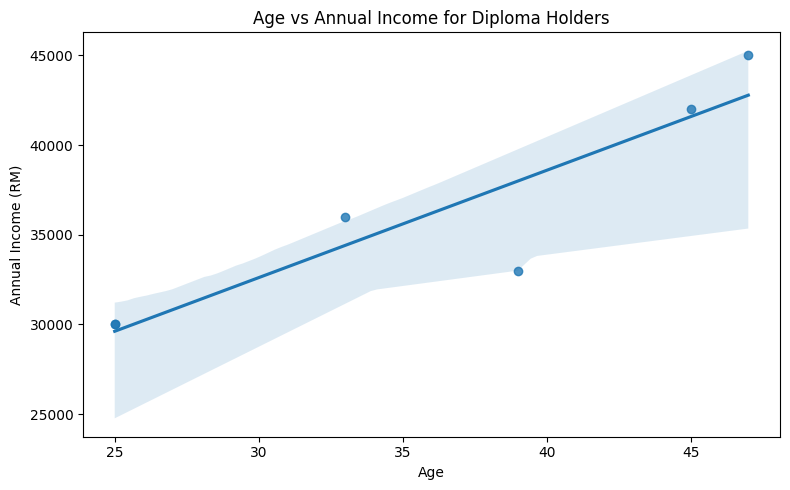

In [25]:
# Visualise the relationship between age and annual income

plt.figure(figsize=(8, 5))

sns.regplot(
    data=diploma_df,
    x="Age",
    y="Annual Income"
)

plt.title("Age vs Annual Income for Diploma Holders")
plt.xlabel("Age")
plt.ylabel("Annual Income (RM)")
plt.tight_layout()
plt.show()

In [26]:
# Question 4: Estimated income of a Diploma holder at age 40

age_40 = 40

predicted_income = (
    regression.intercept +
    regression.slope * age_40
)

predicted_monthly_income = predicted_income / 12

print(f"Estimated annual income at age 40: RM{predicted_income:,.2f}")
print(f"Estimated monthly income at age 40: RM{predicted_monthly_income:,.2f}")

Estimated annual income at age 40: RM38,592.49
Estimated monthly income at age 40: RM3,216.04


In [27]:
print(
    f"Regression equation: "
    f"Annual Income = {regression.intercept:,.2f} + "
    f"({regression.slope:,.2f} × Age)"
)

Regression equation: Annual Income = 14,661.85 + (598.27 × Age)


In [28]:
# Q5: What kind of phone does someone earning RM5,000+ per month possess?

# RM5,000 per month = RM60,000 per year
annual_income_threshold = 5000 * 12

# Filter customers earning RM5,000 or more per month
high_income_df = df[df["Annual Income"] >= annual_income_threshold].copy()

print(f"Annual income threshold: RM{annual_income_threshold:,.0f}")
print("\nCustomers earning RM5,000+ per month:")
display(high_income_df[["Name", "Annual Income", "Phone Owned"]])

Annual income threshold: RM60,000

Customers earning RM5,000+ per month:


,Name,Annual Income,Phone Owned
6,Pierre,120000,Nokia E63
7,Valerie,80000,iPhone 3Gs
16,Wong,110000,iPhone 6s+
17,Jill,75000,iPhone 6s


In [29]:
# Extract the phone brand from the Phone Owned column

phone_brands = (
    high_income_df["Phone Owned"]
    .str.split()
    .str[0]
)

print("\nPhone brands among customers earning RM5,000+ per month:")
print(phone_brands.value_counts())


Phone brands among customers earning RM5,000+ per month:
Phone Owned
iPhone    3
Nokia     1
Name: count, dtype: int64


In [32]:
# Q6: Most preferred way of requesting an interview
# for someone who spends more than RM2,000 on their phone

# Assumption:
# These phone models are estimated to cost more than RM2,000
phones_over_2000 = [
    "iPhone 5",
    "iPhone 5s",
    "iPhone 6s",
    "iPhone 6+",
    "iPhone 6s+",
    "iPhone 3Gs"
]

# Filter customers with phones estimated above RM2,000
high_phone_spend = df[df["Phone Owned"].isin(phones_over_2000)].copy()

print("Customers with phones estimated to cost more than RM2,000:")
display(high_phone_spend[["Name", "Phone Owned"]])

# Interview request methods
interview_methods = [
    "Email",
    "Web",
    "Mobile",
    "Walk-in",
    "Video Call",
    "Phone Call",
    "Letter"
]

# Count the number of customers using each method
method_counts = high_phone_spend[interview_methods].sum()

print("\nInterview request methods:")
print(method_counts.sort_values(ascending=False))

Customers with phones estimated to cost more than RM2,000:


,Name,Phone Owned
2,Lim,iPhone 5
3,Angie,iPhone 6s
7,Valerie,iPhone 3Gs
10,Regina,iPhone 6+
14,Abdullah,iPhone 5s
16,Wong,iPhone 6s+
17,Jill,iPhone 6s



Interview request methods:
Email         7
Video Call    7
Web           5
Mobile        4
Phone Call    2
Letter        2
Walk-in       1
dtype: int64
